##Лабораторная работа №2. Классификация $kNN$

Выполнил студент группы 6401-010302D Смирнов Андрей Александрович






In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as pl
from pathlib import Path
import kagglehub
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

In [143]:
# Метод для расчета и вывода метрик
def print_classification_metrics(model, X_test, y_test, title):
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  if (len(np.unique(y_test)) > 2):
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
  else:
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

  if title:
    print(f'--- {title} ---\n')
  print(f'Accuracy: {accuracy:.4f}')
  print(f'Precision: {precision:.4f}')
  print(f'Recall: {recall:.4f}')
  print(f'F1: {f1:.4f}')
  print(f'Classification report:\n{classification_report(y_test, y_pred)}')

## 2. Бинарная классификация:

- Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

In [144]:
# Датасет для бинарной классификации
df = pd.read_csv("/content/bank-full.csv", delimiter=';')
pd.set_option('display.max_columns', None)

df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


- Привести описание датасета.



Датасет содержит данные о результатах маркетинговой программы банка, полученных в ходе звонков клиентам.
Целевой признак:
- Бинарная классификация - y ('yes'/'no' согласился ли клиент на депозит)

| Признак | Описание | Тип / Единицы измерения  
   | --- | --- | --- |  
age |	Возраст	|	Числовой
job | Работа | Категориальный
marital | Семейный статус | Категориальный
education | Уровень образования | Категориальныый
default | Есть ли невыплаченный кредит | Бинарный
balance | Среднегодовой баланс | Числовой
housing | Есть ли ипотека | Бинарный
loan | Есть ли кредит для личного пользования | Бинарный
contact | Способ контакта | Категориальный
day | День последнего контакта | Дата
month | Месяц последнего контакта | Дата
duration | Длительность контакта | Числовой
campaign | Число контактов с клиентом за текущую компанию | Числовой
pdays | Число дней с последнего контакта | Числовой, -1 если это первый контакт
previous | Число контактов с клиентом за время предыдущих компаний | Числовой
poutcome | Исход предыдущей компании | Категориальный

- Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные".


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [146]:
df = df.drop(columns=['duration', 'pdays', 'month', 'day']) # Убираем лишние признаки

df.dropna()

df

,age,job,marital,education,default,balance,housing,loan,contact,campaign,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,3,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,2,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,5,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,4,0,unknown,no


- Закодировать категориальные признаки при необходимости.

In [147]:
cat_cols = [var for var in df.columns if df[var].dtype == 'object']

len_max = max([len(col) for col in cat_cols])
for col in cat_cols:
    print(f"{col:<{len_max}} labels: {len(df[col].unique())}")

job       labels: 12
marital   labels: 3
education labels: 4
default   labels: 2
housing   labels: 2
loan      labels: 2
contact   labels: 3
poutcome  labels: 4
y         labels: 2


In [148]:
# Кодируем бинарные категориальные переменные
for col in ['housing', 'loan', 'default', 'y']:
  df[col] = df[col].map({'no':0, 'yes':1}).astype(np.uint8)

# Кодируем небинарные категориальные переменные
for col in ['job', 'marital', 'education', 'contact', 'poutcome']:
  df_dummies = pd.get_dummies(df[col], prefix=col)
  df = df.drop(columns=col)
  df = df.join(df_dummies)

df

,age,default,balance,housing,loan,campaign,previous,y,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,1,0,0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,44,0,29,1,0,1,0,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,True
2,33,0,2,1,1,1,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True
3,47,0,1506,1,0,1,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True
4,33,0,1,0,0,1,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,0,825,0,0,3,0,1,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True
45207,71,0,1729,0,0,2,0,1,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,True
45208,72,0,5715,0,0,5,3,1,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
45209,57,0,668,0,0,4,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


- Разбить выборку на обучающую и тестовую.

In [149]:
y = df['y']
X = df.drop('y', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 - При наличии дисбаланса классов снизить дисбаланс классов
 - Выбрать какое-нибудь значение гиперпараметра $k$ алгоритма $kNN$.
   
     > Разбиение использовать одно и то же для всех последующих манипуляций.

 - Осуществить бинарную классификацию.
 - Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [150]:
# Для снижения дисбаланса классов используем параметр весов в knn
knn_classifier_bin_base = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

knn_classifier_bin_base.fit(X_train, y_train)

print_classification_metrics(knn_classifier_bin_base,
                             X_test,
                             y_test,
                             'Бинарная классификация на ненормированных признаках c балансировкой классов')

--- Бинарная классификация на ненормированных признаках c балансировкой классов ---

Accuracy: 0.8753
Precision: 0.4488
Recall: 0.1485
F1: 0.2231
Classification report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      7952
           1       0.45      0.15      0.22      1091

    accuracy                           0.88      9043
   macro avg       0.67      0.56      0.58      9043
weighted avg       0.84      0.88      0.85      9043



   - Нормализовать данные (`StandardScaler`или `MinMaxScaler`).

In [151]:
scaler = sklearn.preprocessing.MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index= X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index= X_test.index)

X_train_scaled

,age,default,balance,housing,loan,campaign,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
3344,0.298701,0.0,0.080511,1.0,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
17965,0.402597,0.0,0.085650,1.0,0.0,0.016129,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
18299,0.311688,0.0,0.107684,0.0,0.0,0.048387,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
10221,0.246753,0.0,0.071723,1.0,0.0,0.161290,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
32192,0.493506,0.0,0.104561,0.0,0.0,0.016129,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.337662,0.0,0.082418,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
44732,0.064935,0.0,0.077415,0.0,0.0,0.000000,0.003636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
38158,0.207792,0.0,0.084760,1.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
860,0.194805,0.0,0.074301,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


- Осуществить бинарную классификацию.
- Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [152]:
knn_classifier_bin_scaled = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

knn_classifier_bin_scaled.fit(X_train_scaled, y_train)

print_classification_metrics(knn_classifier_bin_scaled,
                             X_test_scaled,
                             y_test,
                             'Бинарная классификация на нормированных признаках c балансировкой классов')

--- Бинарная классификация на нормированных признаках c балансировкой классов ---

Accuracy: 0.8630
Precision: 0.3833
Recall: 0.2227
F1: 0.2817
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7952
           1       0.38      0.22      0.28      1091

    accuracy                           0.86      9043
   macro avg       0.64      0.59      0.60      9043
weighted avg       0.84      0.86      0.85      9043



- Сравнить метрики на данных без нормализации и с применением нормализации.

In [153]:
print_classification_metrics(knn_classifier_bin_base,
                             X_test,
                             y_test,
                             'До нормирования')

print_classification_metrics(knn_classifier_bin_scaled,
                             X_test_scaled,
                             y_test,
                             'После нормирования')

--- До нормирования ---

Accuracy: 0.8753
Precision: 0.4488
Recall: 0.1485
F1: 0.2231
Classification report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      7952
           1       0.45      0.15      0.22      1091

    accuracy                           0.88      9043
   macro avg       0.67      0.56      0.58      9043
weighted avg       0.84      0.88      0.85      9043

--- После нормирования ---

Accuracy: 0.8630
Precision: 0.3833
Recall: 0.2227
F1: 0.2817
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7952
           1       0.38      0.22      0.28      1091

    accuracy                           0.86      9043
   macro avg       0.64      0.59      0.60      9043
weighted avg       0.84      0.86      0.85      9043



**Сравнение метрик**:

При использовании нормированных признаков все показатели ($accuracy$, $precision$, $recall$, $f1-score$) упали.

Обычно модель `KNeighborsClassifier` показывает себя лучше на нормированных признаках, поскольку тогда масштаб признаков не влияет на важность признака. Однако в данном случае роль может играть большое количество категориальных признаков, имеющих одинаковый масштаб, и нормализация числовых признаков понижает точность модели.

 - Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`. Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений (***см. [примечание](#примечание)***).

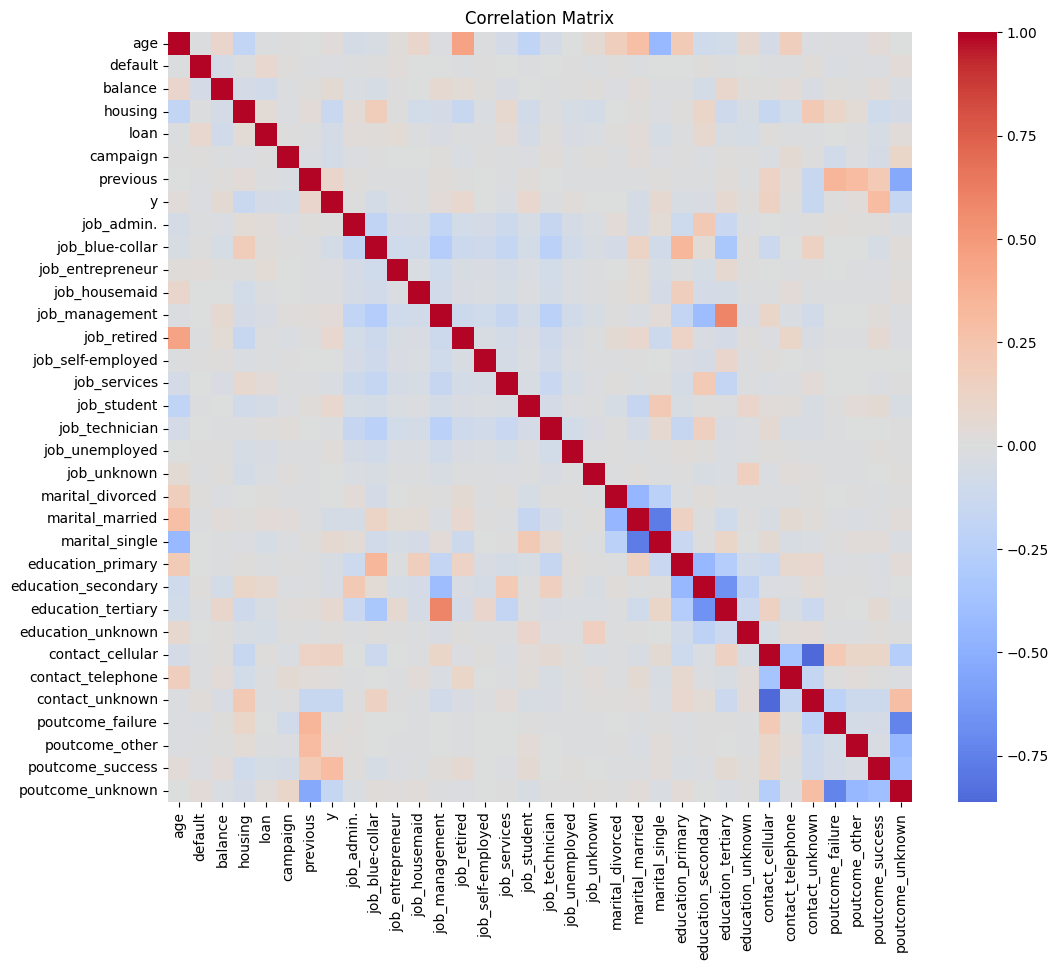

In [154]:
corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [155]:
# Отбор признаков
sfs = SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=10, direction='forward')

sfs.fit(X_train_scaled, y_train)

sfs_cols = np.array(X.columns[sfs.get_support()])

print(f'Отобранные SFS признаки: {sfs_cols}')

Отобранные SFS признаки: ['housing' 'loan' 'campaign' 'job_retired' 'job_student' 'marital_married'
 'education_tertiary' 'contact_unknown' 'poutcome_other'
 'poutcome_success']


- Осуществить бинарную классификацию с отфильтрованными признаками.
   - Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [156]:
knn_classifier_bin_filtered = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

knn_classifier_bin_filtered.fit(X_train_scaled[sfs_cols], y_train)

print_classification_metrics(knn_classifier_bin_filtered,
                             X_test_scaled[sfs_cols],
                             y_test,
                             "Бинарная классификация на отфильтрованных нормированных признаках c балансировкой классов")

--- Бинарная классификация на отфильтрованных нормированных признаках c балансировкой классов ---

Accuracy: 0.8859
Precision: 0.5855
Recall: 0.1852
F1: 0.2813
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.59      0.19      0.28      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.58      0.61      9043
weighted avg       0.86      0.89      0.86      9043



In [157]:
print_classification_metrics(knn_classifier_bin_scaled,
                             X_test_scaled,
                             y_test,
                             'До фильтрации')

print_classification_metrics(knn_classifier_bin_filtered,
                             X_test_scaled[sfs_cols],
                             y_test,
                             "После фильтрации")

--- До фильтрации ---

Accuracy: 0.8630
Precision: 0.3833
Recall: 0.2227
F1: 0.2817
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7952
           1       0.38      0.22      0.28      1091

    accuracy                           0.86      9043
   macro avg       0.64      0.59      0.60      9043
weighted avg       0.84      0.86      0.85      9043

--- После фильтрации ---

Accuracy: 0.8859
Precision: 0.5855
Recall: 0.1852
F1: 0.2813
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.59      0.19      0.28      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.58      0.61      9043
weighted avg       0.86      0.89      0.86      9043



   - Сравнить результаты "до" и "после" фильтрации, сделать выводы.
     > Естественно, искомые результаты &ndash; улучшение метрик.


**Результаты фильтрации**:

Как видно, фильтрация признаков позволила повысить качество классификации. Это объясняется тем, что отсеиваются малоинформативные признаки, значение которых может не коррелировать с целевой переменной и создавать шум.

Фильтрация признаков в целом положительно сказывается на результатах классификации, однако стоит отметить, что число отфильтрованных признаков должно соотноситься с числом изначальных признаков. Если взять слишком мало признаков, отсеянными могут оказаться информативные признаки. В таком случае качество классификации может снизиться

   - Перебрать значения гиперпараметра $k$ в каком-нибудь диапазоне с использованием кросс-валидации на данных
     > данных &ndash; исходных данных до разбиения с применением нормализации
   
     с отфильтрованными признаками. Построить график *train/test accuracy* в зависимости от значения $k$.

Fitting 5 folds for each of 4 candidates, totalling 20 fits


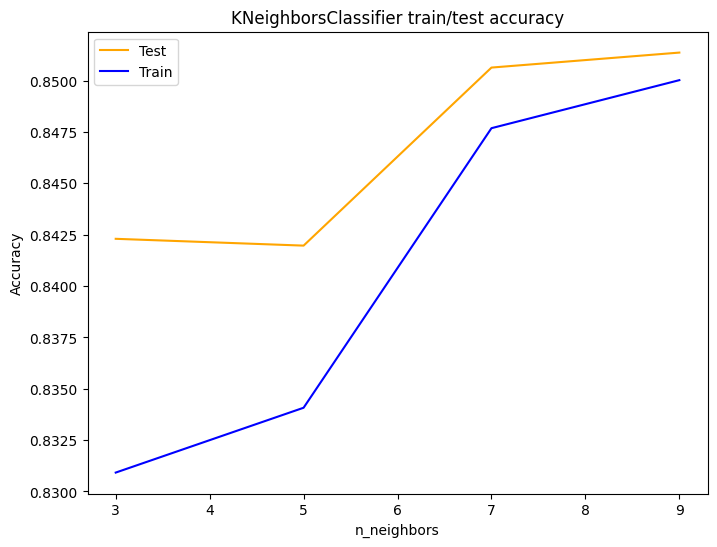

In [158]:
model=KNeighborsClassifier()

n_neighbors = [3, 5, 7, 9]

grid = GridSearchCV(
      estimator=model,
      param_grid={'n_neighbors': n_neighbors},
      cv=5,
      scoring='accuracy',
      n_jobs=-1,
      verbose=1,
      return_train_score=True
  )

grid.fit(X[sfs_cols], y)

plt.figure(figsize=(8, 6))
plt.plot(n_neighbors, grid.cv_results_['mean_test_score'], c='orange', label='Test')
plt.plot(n_neighbors, grid.cv_results_['mean_train_score'], c='blue', label='Train')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('KNeighborsClassifier train/test accuracy')
plt.legend()
plt.show()

## 3. Многоклассовая классификация:



- Привести описание датасета.
 Данные получены в результате обработки изображений дефектов стальных пластин и содержат 27 числовых характеристик, описывающих геометрию дефекта и его положение на пластине.

Целевой признак:

Многоклассовая классификация - Тип дефекта (Pastry, Z_Scratch, K_Scratch,Stains, Dirtiness, Bumps, Other_Faults)
| Признак | Описание | Тип / Единицы измерения |
| --- | --- | --- |
| **X_Minimum** | Минимальная координата дефекта по оси X (в пикселях) | Числовой / пиксель |
| **X_Maximum** | Максимальная координата дефекта по оси X | Числовой / пиксель |
| **Y_Minimum** | Минимальная координата дефекта по оси Y | Числовой / пиксель |
| **Y_Maximum** | Максимальная координата дефекта по оси Y | Числовой / пиксель |
| **Pixels_Areas** | Площадь дефекта (количество пикселей) | Числовой / пиксель² |
| **X_Perimeter** | Периметр дефекта по оси X (проекция на горизонтальную ось) | Числовой / пиксель |
| **Y_Perimeter** | Периметр дефекта по оси Y (проекция на вертикальную ось) | Числовой / пиксель |
| **Sum_of_Luminosity** | Суммарная яркость пикселей в области дефекта | Числовой / усл. ед. |
| **Maximum_of_Luminosity** | Максимальная яркость пикселя в области дефекта | Числовой / усл. ед. |
| **Minimum_of_Luminosity** | Минимальная яркость пикселя в области дефекта | Числовой / усл. ед. |
| **Length_of_Conveyer** | Положение пластины на конвейере (индекс) | Числовой / усл. ед. |
| **TypeOfSteel_A300** | Индикатор типа стали A300 (1 — да, 0 — нет) | Бинарный / 0 или 1 |
| **TypeOfSteel_A400** | Индикатор типа стали A400 (1 — да, 0 — нет) | Бинарный / 0 или 1 |
| **Steel_Plate_Thickness** | Толщина стальной пластины | Числовой / мм |
| **Edges_Index** | Индекс, показывающий близость дефекта к краю пластины | Числовой / усл. ед. |
| **Empty_Index** | Мера «пустоты» или разреженности области дефекта | Числовой / усл. ед. |
| **Square_Index** | Показатель, насколько форма дефекта близка к квадрату | Числовой / усл. ед. |
| **Outside_X_Index** | Показатель выхода дефекта за границы пластины по оси X | Числовой / усл. ед. |
| **Edges_X_Index** | Индекс, оценивающий пересечение границ дефекта с краями пластины по оси X | Числовой / усл. ед. |
| **Edges_Y_Index** | Индекс, оценивающий пересечение границ дефекта с краями пластины по оси Y | Числовой / усл. ед. |
| **Outside_Global_Index** | Обобщённый показатель выхода дефекта за границы пластины | Числовой / усл. ед. |
| **LogOfAreas** | Логарифм площади дефекта (логарифмическая шкала для широкого диапазона размеров) | Числовой / log(пиксель²) |
| **Log_X_Index** | Логарифм от координаты X (для нормализации или масштабирования) | Числовой / log(пиксель) |
| **Log_Y_Index** | Логарифм от координаты Y | Числовой / log(пиксель) |
| **Orientation_Index** | Индекс, определяющий ориентацию дефекта (например, угол наклона) | Числовой / усл. ед. |
| **Luminosity_Index** | Индекс яркости дефекта (вероятно, нормализованное значение на основе Minimum/Maximum яркости) | Числовой / усл. ед. |
| **SigmoidOfAreas** | Результат применения сигмоидальной функции к площади дефекта (нелинейное масштабирование) | Числовой / усл. ед. |

In [159]:
# Датасет для многоклассовой классификации
df = pd.read_table("/content/Faults.NNA", delimiter='\t', header=None)
pd.set_option('display.max_columns', None)

# Подпишем признаки
df.columns = ["X_Minimum", "X_Maximum", "Y_Minimum", "Y_Maximum", "Pixels_Areas", "X_Perimeter",\
              "Y_Perimeter", "Sum_of_Luminosity", "Maximum_of_Luminosity", "Length_of_Conveyer",\
              "TypeOfSteel_A300", "TypeOfSteel_A400", "Steel_Plate_Thickness", "Edges_Index",\
              "Empty_Index", "Square_Index", "Outside_X_Index", "Edges_X_Index", "Edges_Y_Index",\
              "Outside_Global_Index", "LogOfAreas", "Log_X_Index", "Log_Y_Index", "Orientation_Index",\
              "Luminosity_Index", "SigmoidOfAreas", "Minimum_of_Luminosity", "Pastry", "Z_Scratch",\
              "K_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

df

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,1623,1,0,100,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,1353,0,1,290,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,1353,0,1,185,0.0695,0.4486,0.0662,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,249,277,325780,325796,273,54,22,35033,119,141,1360,0,1,40,0.3662,0.3906,0.5714,0.0206,0.5185,0.7273,0.0,2.4362,1.4472,1.2041,-0.4286,0.0026,0.7254,0,0,0,0,0,0,1
1937,144,175,340581,340598,287,44,24,34599,112,133,1360,0,1,40,0.2118,0.4554,0.5484,0.0228,0.7046,0.7083,0.0,2.4579,1.4914,1.2305,-0.4516,-0.0582,0.8173,0,0,0,0,0,0,1
1938,145,174,386779,386794,292,40,22,37572,120,140,1360,0,1,40,0.2132,0.3287,0.5172,0.0213,0.7250,0.6818,0.0,2.4654,1.4624,1.1761,-0.4828,0.0052,0.7079,0,0,0,0,0,0,1
1939,137,170,422497,422528,419,97,47,52715,117,140,1360,0,1,40,0.2015,0.5904,0.9394,0.0243,0.3402,0.6596,0.0,2.6222,1.5185,1.4914,-0.0606,-0.0171,0.9919,0,0,0,0,0,0,1


 - Осуществить предобработку данных &ndash; "подчистить данные".
 - Закодировать категориальные признаки при необходимости.



In [160]:
df = df.dropna()

# Целевая переменная в one-hot, переведем ее в label
target_cols = ["Pastry", "Z_Scratch",\
              "K_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

# Проверим, что в каждой строке только одна единица
assert (df[target_cols].sum(axis=1) == 1).all(), "Есть строки с несколькими дефектами"

# Создаем новую колонку 'fault_type' с названием дефекта
df['fault_type'] = df[target_cols].idxmax(axis=1)

# map вместо LabelEncoder чтобы самому определять номера классов
df['fault_type'] = df['fault_type'].map({"Pastry":0, "Z_Scratch":1,\
              "K_Scratch":2, "Stains":3, "Dirtiness":4, "Bumps":5, "Other_Faults":6})

df = df.drop(columns=target_cols)

df

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity,fault_type
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,1623,1,0,100,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,0
3,853,860,369370,369415,176,13,45,18996,99,126,1353,0,1,290,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,1353,0,1,185,0.0695,0.4486,0.0662,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,249,277,325780,325796,273,54,22,35033,119,141,1360,0,1,40,0.3662,0.3906,0.5714,0.0206,0.5185,0.7273,0.0,2.4362,1.4472,1.2041,-0.4286,0.0026,0.7254,6
1937,144,175,340581,340598,287,44,24,34599,112,133,1360,0,1,40,0.2118,0.4554,0.5484,0.0228,0.7046,0.7083,0.0,2.4579,1.4914,1.2305,-0.4516,-0.0582,0.8173,6
1938,145,174,386779,386794,292,40,22,37572,120,140,1360,0,1,40,0.2132,0.3287,0.5172,0.0213,0.7250,0.6818,0.0,2.4654,1.4624,1.1761,-0.4828,0.0052,0.7079,6
1939,137,170,422497,422528,419,97,47,52715,117,140,1360,0,1,40,0.2015,0.5904,0.9394,0.0243,0.3402,0.6596,0.0,2.6222,1.5185,1.4914,-0.0606,-0.0171,0.9919,6


 - Разбить выборку на обучающую и тестовую.
     > Разбиение использовать одно и то же для данных без фильтрации признаков и с применением фильтрации.


In [161]:
y = df['fault_type']
X = df.drop('fault_type', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 - Нормализовать данные.

In [162]:
scaler = sklearn.preprocessing.MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index= X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index= X_test.index)

X_train_scaled

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity
1917,0.090323,0.096548,0.019522,0.019522,0.000478,0.002393,0.000881,0.000836,0.637755,0.490741,0.241623,0.0,1.0,0.000000,0.226889,0.617968,0.798326,0.010865,0.549107,0.690942,0.0,0.322383,0.315567,0.253411,0.398951,0.617424,0.213167
808,0.657478,0.657695,0.137326,0.137325,0.000098,0.000670,0.000275,0.000171,0.586735,0.523148,0.234568,0.0,1.0,0.038462,0.342846,0.544867,0.711909,0.004231,0.774554,0.824821,0.0,0.190366,0.196206,0.164135,0.355727,0.612741,0.028490
680,0.024047,0.124049,0.208164,0.208167,0.041244,0.026132,0.007327,0.056455,0.214286,0.412037,0.231041,0.0,1.0,0.000000,0.060691,0.434368,0.343148,0.145700,0.631088,0.427491,0.0,0.716448,0.700299,0.419212,0.171282,0.463085,1.000000
534,0.075660,0.089526,0.006139,0.006140,0.001795,0.003542,0.001377,0.002899,0.586735,0.453704,0.238095,0.0,1.0,0.000000,0.190314,0.509800,0.675910,0.021844,0.713778,0.717108,0.0,0.438262,0.413328,0.300256,0.337721,0.563843,0.798297
192,0.255718,0.256290,0.040387,0.040387,0.000400,0.001436,0.000881,0.000528,0.459184,0.365741,0.227513,1.0,0.0,0.115385,0.646202,0.405022,0.347484,0.003317,0.343446,1.000000,1.0,0.306859,0.172082,0.288938,0.826197,0.448140,0.101362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.699120,0.702750,0.039689,0.039689,0.000649,0.001914,0.000661,0.000979,0.551020,0.407407,0.227513,0.0,1.0,0.000000,0.223774,0.426316,1.000000,0.009263,0.584923,1.000000,0.5,0.348844,0.293138,0.261559,0.499823,0.521763,0.195687
1294,0.008211,0.011703,0.010965,0.010966,0.000970,0.000957,0.001157,0.001493,0.505102,0.476852,0.811287,0.0,1.0,0.615385,0.016680,0.337112,0.449934,0.005032,0.830864,1.000000,1.0,0.384029,0.252064,0.315214,0.774903,0.533884,0.280704
860,0.360704,0.361615,0.168054,0.168054,0.000360,0.001053,0.000771,0.000544,0.545918,0.416667,0.245150,0.0,1.0,0.230769,0.904743,0.484267,0.462237,0.004117,0.531757,1.000000,1.0,0.297970,0.196206,0.276164,0.768800,0.523003,0.105108
1459,0.129032,0.131656,0.237864,0.237864,0.000341,0.000766,0.000496,0.000503,0.530612,0.402778,0.820106,0.0,1.0,0.115385,0.261254,0.423774,0.899163,0.004346,0.898539,1.000000,1.0,0.293157,0.235549,0.234813,0.550260,0.510675,0.086720


- При наличии дисбаланса классов снизить дисбаланс классов
- Выбрать какое-нибудь значение гиперпараметра $k$ алгоритма $kNN$.
- Осуществить многоклассовую классификацию.
- Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [163]:
# Для снижения дисбаланса классов используем параметр весов в knn
knn_classifier_mul_scaled = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

knn_classifier_mul_scaled.fit(X_train_scaled, y_train)

print_classification_metrics(knn_classifier_mul_scaled,
                             X_test_scaled,
                             y_test,
                             'Многоклассовая классификация на нормированных признаках c балансировкой классов')

--- Многоклассовая классификация на нормированных признаках c балансировкой классов ---

Accuracy: 0.7172
Precision: 0.7162
Recall: 0.7172
F1: 0.7137
Classification report:
              precision    recall  f1-score   support

           0       0.40      0.34      0.37        29
           1       0.76      0.93      0.84        41
           2       0.94      0.94      0.94        83
           3       0.75      0.92      0.83        13
           4       0.55      0.75      0.63         8
           5       0.58      0.64      0.61        72
           6       0.71      0.62      0.66       143

    accuracy                           0.72       389
   macro avg       0.67      0.74      0.70       389
weighted avg       0.72      0.72      0.71       389



- Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`.

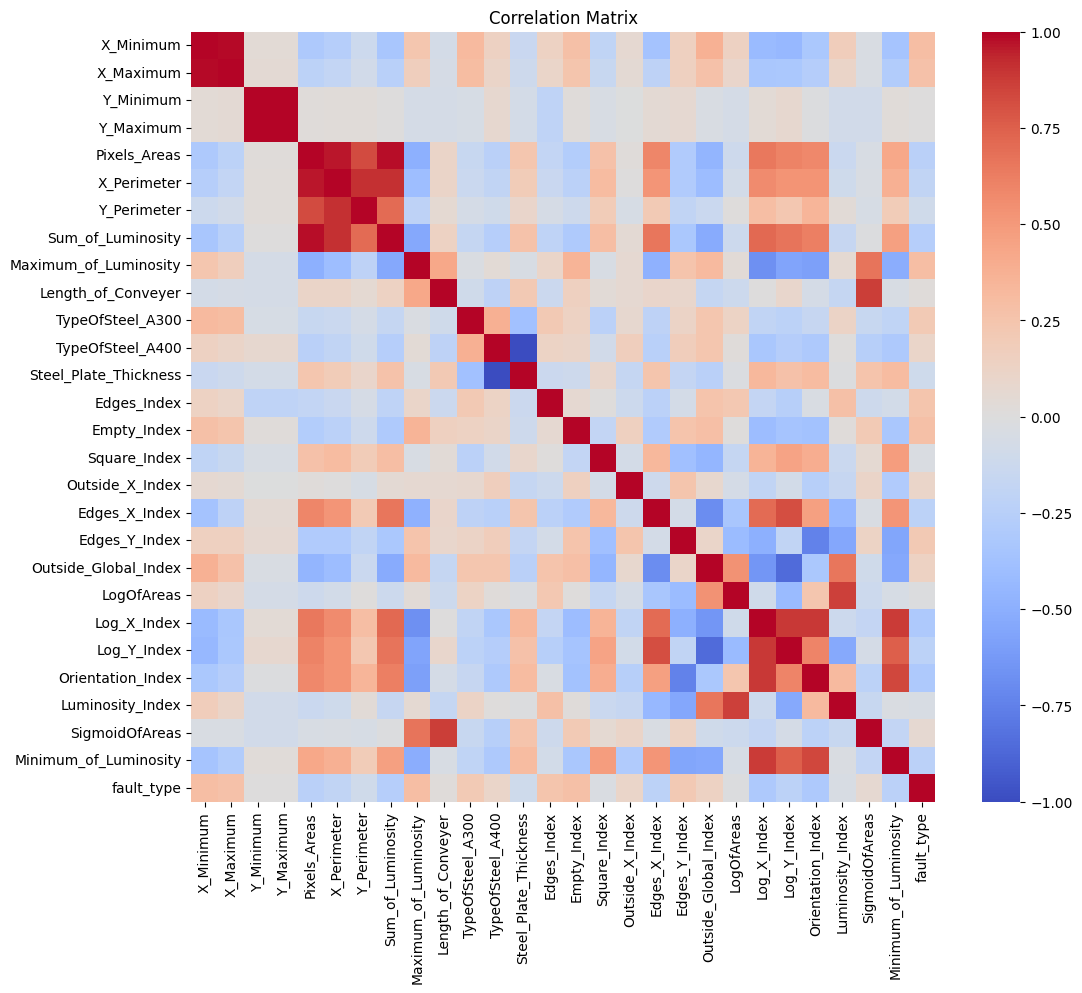

In [164]:
corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

- Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений (***см. [примечание](#примечание)***).

In [165]:
# Отбор признаков
sfs = SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=15, direction='forward')

sfs.fit(X_train_scaled, y_train)

sfs_cols_mul = np.array(X.columns[sfs.get_support()])

print(f'Отобранные SFS признаки: {sfs_cols_mul}')

Отобранные SFS признаки: ['X_Maximum' 'Y_Maximum' 'Y_Perimeter' 'Maximum_of_Luminosity'
 'Length_of_Conveyer' 'TypeOfSteel_A300' 'Steel_Plate_Thickness'
 'Edges_Index' 'Empty_Index' 'Square_Index' 'Outside_X_Index' 'LogOfAreas'
 'Log_Y_Index' 'Orientation_Index' 'SigmoidOfAreas']


   - Осуществить многоклассовую классификацию с отфильтрованными признаками.
   - Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.
  

     


In [166]:
# Для снижения дисбаланса классов используем параметр весов в knn
knn_classifier_mul_filtered = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

knn_classifier_mul_filtered.fit(X_train_scaled[sfs_cols_mul], y_train)

print_classification_metrics(knn_classifier_mul_filtered,
                             X_test_scaled[sfs_cols_mul],
                             y_test,
                             'многоклассовая классификация на отфильтрованных нормированных признаках c балансировкой классов')

--- многоклассовая классификация на отфильтрованных нормированных признаках c балансировкой классов ---

Accuracy: 0.7404
Precision: 0.7439
Recall: 0.7404
F1: 0.7370
Classification report:
              precision    recall  f1-score   support

           0       0.52      0.38      0.44        29
           1       0.69      0.90      0.78        41
           2       0.93      0.94      0.93        83
           3       0.92      0.92      0.92        13
           4       0.60      0.75      0.67         8
           5       0.60      0.71      0.65        72
           6       0.76      0.65      0.70       143

    accuracy                           0.74       389
   macro avg       0.72      0.75      0.73       389
weighted avg       0.74      0.74      0.74       389



 - Сравнить результаты "до" и "после" фильтрации, сделать выводы.

In [167]:
print_classification_metrics(knn_classifier_mul_scaled,
                             X_test_scaled,
                             y_test,
                             'До фильтрации')

print_classification_metrics(knn_classifier_mul_filtered,
                             X_test_scaled[sfs_cols_mul],
                             y_test,
                             'После фильтрации')

--- До фильтрации ---

Accuracy: 0.7172
Precision: 0.7162
Recall: 0.7172
F1: 0.7137
Classification report:
              precision    recall  f1-score   support

           0       0.40      0.34      0.37        29
           1       0.76      0.93      0.84        41
           2       0.94      0.94      0.94        83
           3       0.75      0.92      0.83        13
           4       0.55      0.75      0.63         8
           5       0.58      0.64      0.61        72
           6       0.71      0.62      0.66       143

    accuracy                           0.72       389
   macro avg       0.67      0.74      0.70       389
weighted avg       0.72      0.72      0.71       389

--- После фильтрации ---

Accuracy: 0.7404
Precision: 0.7439
Recall: 0.7404
F1: 0.7370
Classification report:
              precision    recall  f1-score   support

           0       0.52      0.38      0.44        29
           1       0.69      0.90      0.78        41
           2       0.93

**Результаты фильтрации**:

Как видно, фильтрация признаков позволила повысить качество классификации. Это объясняется тем, что отсеиваются малоинформативные признаки, значение которых может не коррелировать с целевой переменной и создавать шум.

Фильтрация признаков в целом положительно сказывается на результатах классификации, однако стоит отметить, что число отфильтрованных признаков должно соотноситься с числом изначальных признаков. Если взять слишком мало признаков, отсеянными могут оказаться информативные признаки. В таком случае качество классификации может снизиться


 - Перебрать значения гиперпараметра $k$ в каком-нибудь диапазоне с использованием кросс-валидации на данных с отфильтрованными признаками. Построить график *train/test accuracy* в зависимости от значения $k$.

  

Лучший классификатор: {'n_neighbors': 7}


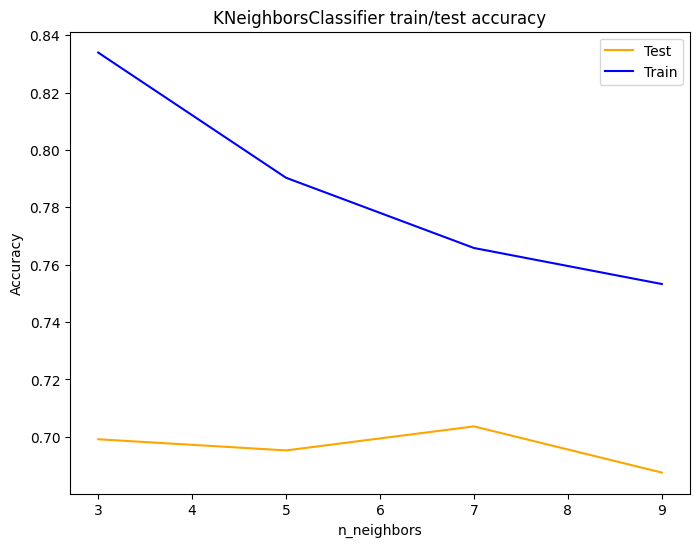

In [169]:
model=KNeighborsClassifier()

n_neighbors = [3, 5, 7, 9]

grid = GridSearchCV(
      estimator=model,
      param_grid={'n_neighbors': n_neighbors},
      cv=5,
      scoring='accuracy',
      n_jobs=-1,
      return_train_score=True
  )

grid.fit(X_train_scaled[sfs_cols_mul], y_train)
print(f'Лучший классификатор: {grid.best_params_}')

plt.figure(figsize=(8, 6))
plt.plot(n_neighbors, grid.cv_results_['mean_test_score'], c='orange', label='Test')
plt.plot(n_neighbors, grid.cv_results_['mean_train_score'], c='blue', label='Train')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('KNeighborsClassifier train/test accuracy')
plt.legend()
plt.show()

- Для лучшего классификатора привести метрики, `classification_report`, построить [confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html) (это вроде матрицы $TN$ / $TP$ / $FN$ / $FP$, только расширенной для многоклассовой классификации, чтобы понять, в какие стороны чаще ошибается классификатор).


Лучшим оказался классификатор c n_neighbors = 7

In [170]:
# Для снижения дисбаланса классов используем параметр весов в knn
knn_classifier_mul_best = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')

knn_classifier_mul_best.fit(X_train_scaled[sfs_cols_mul], y_train)

print_classification_metrics(knn_classifier_mul_best,
                             X_test_scaled[sfs_cols_mul],
                             y_test,
                             'Многоклассовая классификация лучшей моделью на отфильтрованных нормированных признаках c балансировкой классов')

--- Многоклассовая классификация лучшей моделью на отфильтрованных нормированных признаках c балансировкой классов ---

Accuracy: 0.7198
Precision: 0.7272
Recall: 0.7198
F1: 0.7180
Classification report:
              precision    recall  f1-score   support

           0       0.52      0.41      0.46        29
           1       0.70      0.90      0.79        41
           2       0.93      0.93      0.93        83
           3       0.75      0.92      0.83        13
           4       0.60      0.75      0.67         8
           5       0.53      0.64      0.58        72
           6       0.76      0.63      0.69       143

    accuracy                           0.72       389
   macro avg       0.69      0.74      0.71       389
weighted avg       0.73      0.72      0.72       389



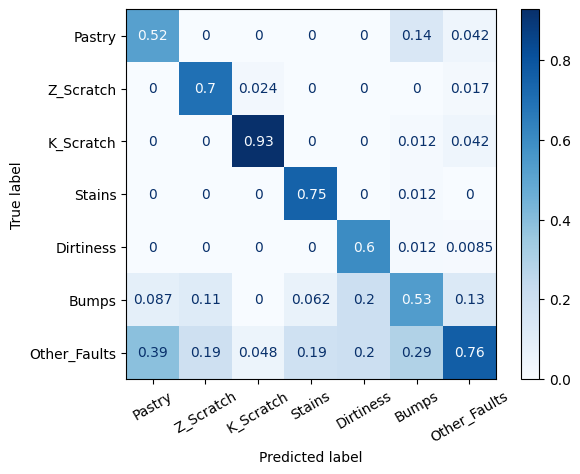

In [171]:
disp = ConfusionMatrixDisplay.from_estimator(
        knn_classifier_mul_best,
        X_test_scaled[sfs_cols_mul],
        y_test,
        display_labels=target_cols,
        cmap=plt.cm.Blues,
        normalize='pred',
        xticks_rotation=30,
        )